# 07 – Decision Tree Model Development

This notebook develops and evaluates baseline and hyperparameter-tuned Decision Tree models for predicting Low, Medium and High waterborne disease risk.

In [1]:
# Import the libraries required for Decision Tree model development

from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

In [2]:
# Define the locations of the prepared datasets, model files, and result files

DATA_PATH = Path("../data/model_input")
MODEL_PATH = Path("../models")
RESULTS_PATH = MODEL_PATH / "results"

MODEL_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print("Data folder:", DATA_PATH.resolve())
print("Model folder:", MODEL_PATH.resolve())
print("Results folder:", RESULTS_PATH.resolve())

Data folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\data\model_input
Model folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models
Results folder: C:\Users\ASUS\Desktop\ICBT Assignments\1. New Batch Assignments\Final Project\Final_Project\models\results


In [3]:
# Load the prepared training and testing datasets

X_train = pd.read_csv(
    DATA_PATH / "X_train.csv"
)

X_test = pd.read_csv(
    DATA_PATH / "X_test.csv"
)

y_train = pd.read_csv(
    DATA_PATH / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    DATA_PATH / "y_test.csv"
).squeeze("columns")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2400, 38)
X_test shape: (600, 38)
y_train shape: (2400,)
y_test shape: (600,)


In [4]:
# Verify the class distribution of the target variable

print("Training Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Training Class Distribution
risk_level
Low       807
High      799
Medium    794
Name: count, dtype: int64

Testing Class Distribution
risk_level
Low       202
High      200
Medium    198
Name: count, dtype: int64


In [5]:
# Create the baseline Decision Tree model

baseline_tree = DecisionTreeClassifier(
    random_state=42
)

print("Baseline Decision Tree model created successfully.")

Baseline Decision Tree model created successfully.


In [6]:
# Train the baseline Decision Tree model and record the training time

start_time = time.time()

baseline_tree.fit(
    X_train,
    y_train
)

baseline_training_time = time.time() - start_time

print(f"Training completed in {baseline_training_time:.4f} seconds.")

Training completed in 0.0381 seconds.


In [7]:
# Generate predictions using the trained baseline Decision Tree model

baseline_train_predictions = baseline_tree.predict(
    X_train
)

baseline_test_predictions = baseline_tree.predict(
    X_test
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [8]:
# Calculate the evaluation metrics for the baseline Decision Tree model

train_accuracy = accuracy_score(
    y_train,
    baseline_train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions
)

precision = precision_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    baseline_test_predictions,
    average="weighted",
    zero_division=0
)

generalisation_gap = train_accuracy - test_accuracy

In [9]:
# Display the evaluation results of the baseline Decision Tree model

print("=" * 50)
print("Baseline Decision Tree Performance")
print("=" * 50)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-Score          : {f1:.4f}")
print(f"Training Time (s) : {baseline_training_time:.4f}")
print(f"Generalisation Gap: {generalisation_gap:.4f}")

Baseline Decision Tree Performance
Training Accuracy : 1.0000
Testing Accuracy  : 0.7833
Precision         : 0.7833
Recall            : 0.7833
F1-Score          : 0.7830
Training Time (s) : 0.0381
Generalisation Gap: 0.2167


In [10]:
# Display the classification report for the baseline Decision Tree model

print("=" * 50)
print("Baseline Decision Tree Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        baseline_test_predictions,
        digits=4,
        zero_division=0
    )
)

Baseline Decision Tree Classification Report
              precision    recall  f1-score   support

        High     0.7915    0.8350    0.8127       200
         Low     0.8776    0.8515    0.8643       202
      Medium     0.6788    0.6616    0.6701       198

    accuracy                         0.7833       600
   macro avg     0.7826    0.7827    0.7824       600
weighted avg     0.7833    0.7833    0.7830       600



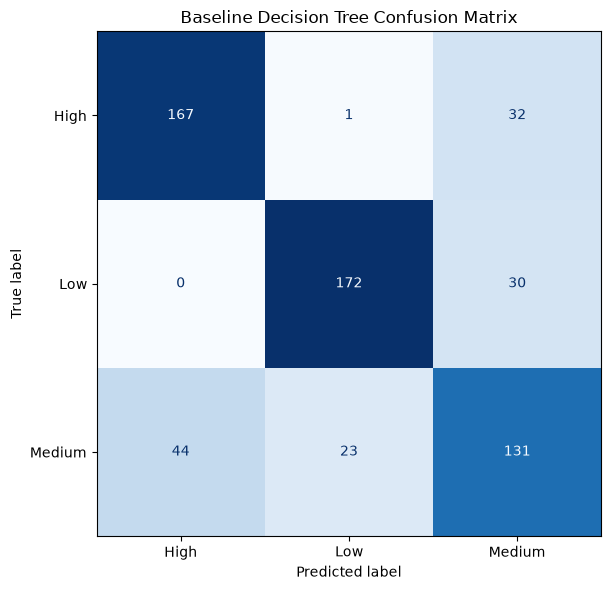

In [11]:
# Display the confusion matrix for the baseline Decision Tree model

baseline_confusion_matrix = confusion_matrix(
    y_test,
    baseline_test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=baseline_confusion_matrix,
    display_labels=baseline_tree.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

display.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Baseline Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
# Define the hyperparameter values to be tested using GridSearchCV

parameter_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}

print("Parameter grid created successfully.")

Parameter grid created successfully.


In [13]:
# Create the GridSearchCV object for Decision Tree hyperparameter tuning

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=parameter_grid,
    scoring="f1_weighted",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("GridSearchCV created successfully.")

GridSearchCV created successfully.


In [14]:
# Perform hyperparameter tuning using GridSearchCV

start_time = time.time()

grid_search.fit(
    X_train,
    y_train
)

tuning_time = time.time() - start_time

print(f"GridSearchCV completed in {tuning_time:.2f} seconds.")

Fitting 5 folds for each of 160 candidates, totalling 800 fits
GridSearchCV completed in 6.94 seconds.


In [15]:
# Display the best hyperparameters identified by GridSearchCV

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2}

Best Cross Validation Score:
0.8458


In [16]:
# Retrieve the best Decision Tree model from GridSearchCV

tuned_tree = grid_search.best_estimator_

print("Tuned Decision Tree model created successfully.")

Tuned Decision Tree model created successfully.


In [17]:
# Generate predictions using the tuned Decision Tree model

tuned_train_predictions = tuned_tree.predict(
    X_train
)

tuned_test_predictions = tuned_tree.predict(
    X_test
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [18]:
# Calculate the evaluation metrics for the tuned Decision Tree model

tuned_train_accuracy = accuracy_score(
    y_train,
    tuned_train_predictions
)

tuned_test_accuracy = accuracy_score(
    y_test,
    tuned_test_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_test_predictions,
    average="weighted",
    zero_division=0
)

tuned_generalisation_gap = (
    tuned_train_accuracy -
    tuned_test_accuracy
)

In [19]:
# Display the evaluation results of the tuned Decision Tree model

print("=" * 50)
print("Tuned Decision Tree Performance")
print("=" * 50)

print(f"Training Accuracy : {tuned_train_accuracy:.4f}")
print(f"Testing Accuracy  : {tuned_test_accuracy:.4f}")
print(f"Precision         : {tuned_precision:.4f}")
print(f"Recall            : {tuned_recall:.4f}")
print(f"F1-Score          : {tuned_f1:.4f}")
print(f"Training Time (s) : {tuning_time:.4f}")
print(f"Generalisation Gap: {tuned_generalisation_gap:.4f}")

Tuned Decision Tree Performance
Training Accuracy : 0.8733
Testing Accuracy  : 0.8083
Precision         : 0.8165
Recall            : 0.8083
F1-Score          : 0.8108
Training Time (s) : 6.9367
Generalisation Gap: 0.0650


In [20]:
# Display the classification report for the tuned Decision Tree model

print("=" * 50)
print("Tuned Decision Tree Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        tuned_test_predictions,
        digits=4,
        zero_division=0
    )
)

Tuned Decision Tree Classification Report
              precision    recall  f1-score   support

        High     0.8689    0.7950    0.8303       200
         Low     0.8912    0.8515    0.8709       202
      Medium     0.6875    0.7778    0.7299       198

    accuracy                         0.8083       600
   macro avg     0.8158    0.8081    0.8103       600
weighted avg     0.8165    0.8083    0.8108       600



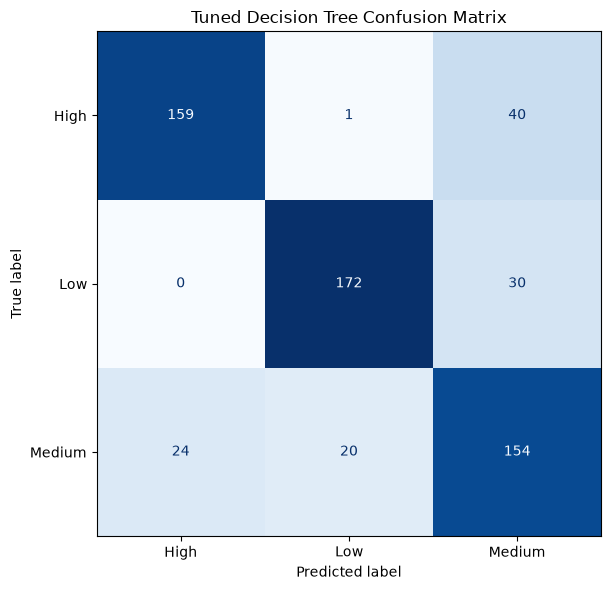

In [21]:
# Display the confusion matrix for the tuned Decision Tree model

tuned_confusion_matrix = confusion_matrix(
    y_test,
    tuned_test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_confusion_matrix,
    display_labels=tuned_tree.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

display.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Tuned Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
# Compare the baseline and tuned Decision Tree models

comparison_results = pd.DataFrame({
    "Model": [
        "Baseline Decision Tree",
        "Tuned Decision Tree"
    ],
    "Training Accuracy": [
        train_accuracy,
        tuned_train_accuracy
    ],
    "Testing Accuracy": [
        test_accuracy,
        tuned_test_accuracy
    ],
    "Precision": [
        precision,
        tuned_precision
    ],
    "Recall": [
        recall,
        tuned_recall
    ],
    "F1-Score": [
        f1,
        tuned_f1
    ],
    "Generalisation Gap": [
        generalisation_gap,
        tuned_generalisation_gap
    ]
})

comparison_results = comparison_results.round(4)

comparison_results

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Generalisation Gap
0,Baseline Decision Tree,1.0000,0.7833,0.7833,0.7833,0.7830,0.2167
1,Tuned Decision Tree,0.8733,0.8083,0.8165,0.8083,0.8108,0.0650


In [23]:
# Select the better Decision Tree model based on the F1-Score

if tuned_f1 > f1:
    final_tree_model = tuned_tree
    selected_model = "Tuned Decision Tree"
else:
    final_tree_model = baseline_tree
    selected_model = "Baseline Decision Tree"

print("=" * 60)
print("Final Decision Tree Model Selection")
print("=" * 60)
print(f"Selected Model : {selected_model}")

if selected_model == "Tuned Decision Tree":
    print(f"Testing Accuracy : {tuned_test_accuracy:.4f}")
    print(f"F1-Score         : {tuned_f1:.4f}")
else:
    print(f"Testing Accuracy : {test_accuracy:.4f}")
    print(f"F1-Score         : {f1:.4f}")

print("\nReason:")
print("The selected model achieved better performance on the independent test dataset while reducing overfitting.")

Final Decision Tree Model Selection
Selected Model : Tuned Decision Tree
Testing Accuracy : 0.8083
F1-Score         : 0.8108

Reason:
The selected model achieved better performance on the independent test dataset while reducing overfitting.


In [24]:
# Save the baseline and tuned Decision Tree models

joblib.dump(
    baseline_tree,
    MODEL_PATH / "decision_tree_baseline.pkl"
)

joblib.dump(
    tuned_tree,
    MODEL_PATH / "decision_tree_tuned.pkl"
)

print("Decision Tree models saved successfully.")

Decision Tree models saved successfully.


In [25]:
# Save the Decision Tree comparison results

comparison_results.to_csv(
    RESULTS_PATH / "decision_tree_results.csv",
    index=False
)

print("Comparison results saved successfully.")

Comparison results saved successfully.


In [26]:
# Save the GridSearchCV results

grid_search_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_search_results.to_csv(
    RESULTS_PATH / "decision_tree_grid_search_results.csv",
    index=False
)

print("GridSearchCV results saved successfully.")

GridSearchCV results saved successfully.


In [27]:
# Save the best hyperparameters

joblib.dump(
    grid_search.best_params_,
    RESULTS_PATH / "decision_tree_best_parameters.pkl"
)

print("Best hyperparameters saved successfully.")

Best hyperparameters saved successfully.


In [28]:
# Verify that all Decision Tree files were saved successfully

files_to_check = [
    MODEL_PATH / "decision_tree_baseline.pkl",
    MODEL_PATH / "decision_tree_tuned.pkl",
    RESULTS_PATH / "decision_tree_results.csv",
    RESULTS_PATH / "decision_tree_grid_search_results.csv",
    RESULTS_PATH / "decision_tree_best_parameters.pkl"
]

print("=" * 60)
print("Generated Files")
print("=" * 60)

for file in files_to_check:
    print(f"{file.name:<55} {file.exists()}")

Generated Files
decision_tree_baseline.pkl                              True
decision_tree_tuned.pkl                                 True
decision_tree_results.csv                               True
decision_tree_grid_search_results.csv                   True
decision_tree_best_parameters.pkl                       True
